# Pre-Period Selector — Recommendations Visualizer

Reads the output of `pps_recommendations` and the raw metric data to visually confirm the top-3 candidate pre-periods.

**Before running:** export data from Postgres using the commands in `integration_tests/README.md`, or use the CSVs already committed in `examples/data/`.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.size':        11,
})

In [12]:
metric = pd.read_csv('data/pps_sample_daily_metric.csv', parse_dates=['date'])
recs   = pd.read_csv('data/pps_recommendations.csv',     parse_dates=['pre_start', 'pre_end'])

POST_START = pd.Timestamp('2024-01-19')

recs = recs.sort_values('recommendation_rank').reset_index(drop=True)
print(recs[['recommendation_rank','pre_start','pre_end','gap_days','diff_corr','composite_score',
            'flag_low_correlation','flag_unstable_gap']].to_string(index=False))

 recommendation_rank  pre_start    pre_end  gap_days  diff_corr  composite_score flag_low_correlation  flag_unstable_gap
                   1 2023-11-03 2023-11-30        50     0.8227           0.8580                    t                NaN
                   2 2023-10-27 2023-11-23        57     0.8782           0.8438                  NaN                NaN
                   3 2023-11-10 2023-12-07        43     0.7244           0.8342                    t                NaN


## 1. Overview — All Candidates on Full Timeline

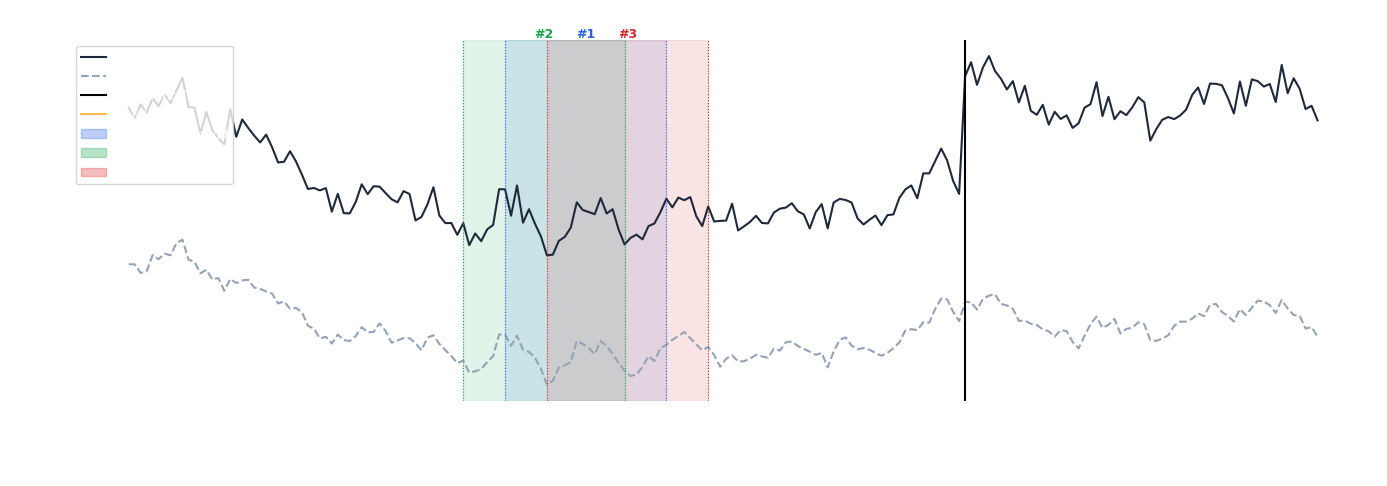

In [13]:
COLORS = ['#2563EB', '#16A34A', '#DC2626']  # rank 1, 2, 3
ALPHA_BAND = 0.12

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(metric['date'], metric['treated_value'], color='#1E293B', lw=1.5, label='Treated')
ax.plot(metric['date'], metric['control_value'], color='#94A3B8', lw=1.5, linestyle='--', label='Control')

# shade each candidate pre-period
for _, row in recs.iterrows():
    rank  = int(row['recommendation_rank'])
    color = COLORS[rank - 1]
    ax.axvspan(row['pre_start'], row['pre_end'], alpha=ALPHA_BAND, color=color)
    ax.axvline(row['pre_start'], color=color, lw=0.8, linestyle=':')
    ax.axvline(row['pre_end'],   color=color, lw=0.8, linestyle=':')
    ax.text(
        row['pre_start'] + (row['pre_end'] - row['pre_start']) / 2,
        ax.get_ylim()[1] if ax.get_ylim()[1] != 1.0 else metric['treated_value'].max(),
        f'#{rank}',
        ha='center', va='bottom', fontsize=9, color=color, fontweight='bold'
    )

# post-period start line
ax.axvline(POST_START, color='black', lw=1.5, linestyle='-', label='Post-period start')

# holidays
holidays = metric[metric['is_holiday'] == True]['date']
for h in holidays:
    ax.axvline(h, color='#F59E0B', lw=0.5, alpha=0.5)

legend_patches = [
    Line2D([0],[0], color='#1E293B', lw=1.5, label='Treated'),
    Line2D([0],[0], color='#94A3B8', lw=1.5, linestyle='--', label='Control'),
    Line2D([0],[0], color='black',   lw=1.5, label='Post-period start'),
    Line2D([0],[0], color='#F59E0B', lw=1.5, alpha=0.7, label='Holiday'),
] + [
    mpatches.Patch(color=COLORS[i], alpha=0.3, label=f'Rank {i+1} pre-period')
    for i in range(len(recs))
]

ax.legend(handles=legend_patches, loc='upper left', fontsize=9, framealpha=0.8)
ax.set_title('Top-3 Candidate Pre-Periods — Full Timeline', fontweight='bold', pad=12)
ax.set_xlabel('Date')
ax.set_ylabel('Metric Value')
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('pre_period_overview.png', dpi=150)
plt.show()

## 2. Per-Candidate Detail — Pre-Period + Gap + Post-Period Start

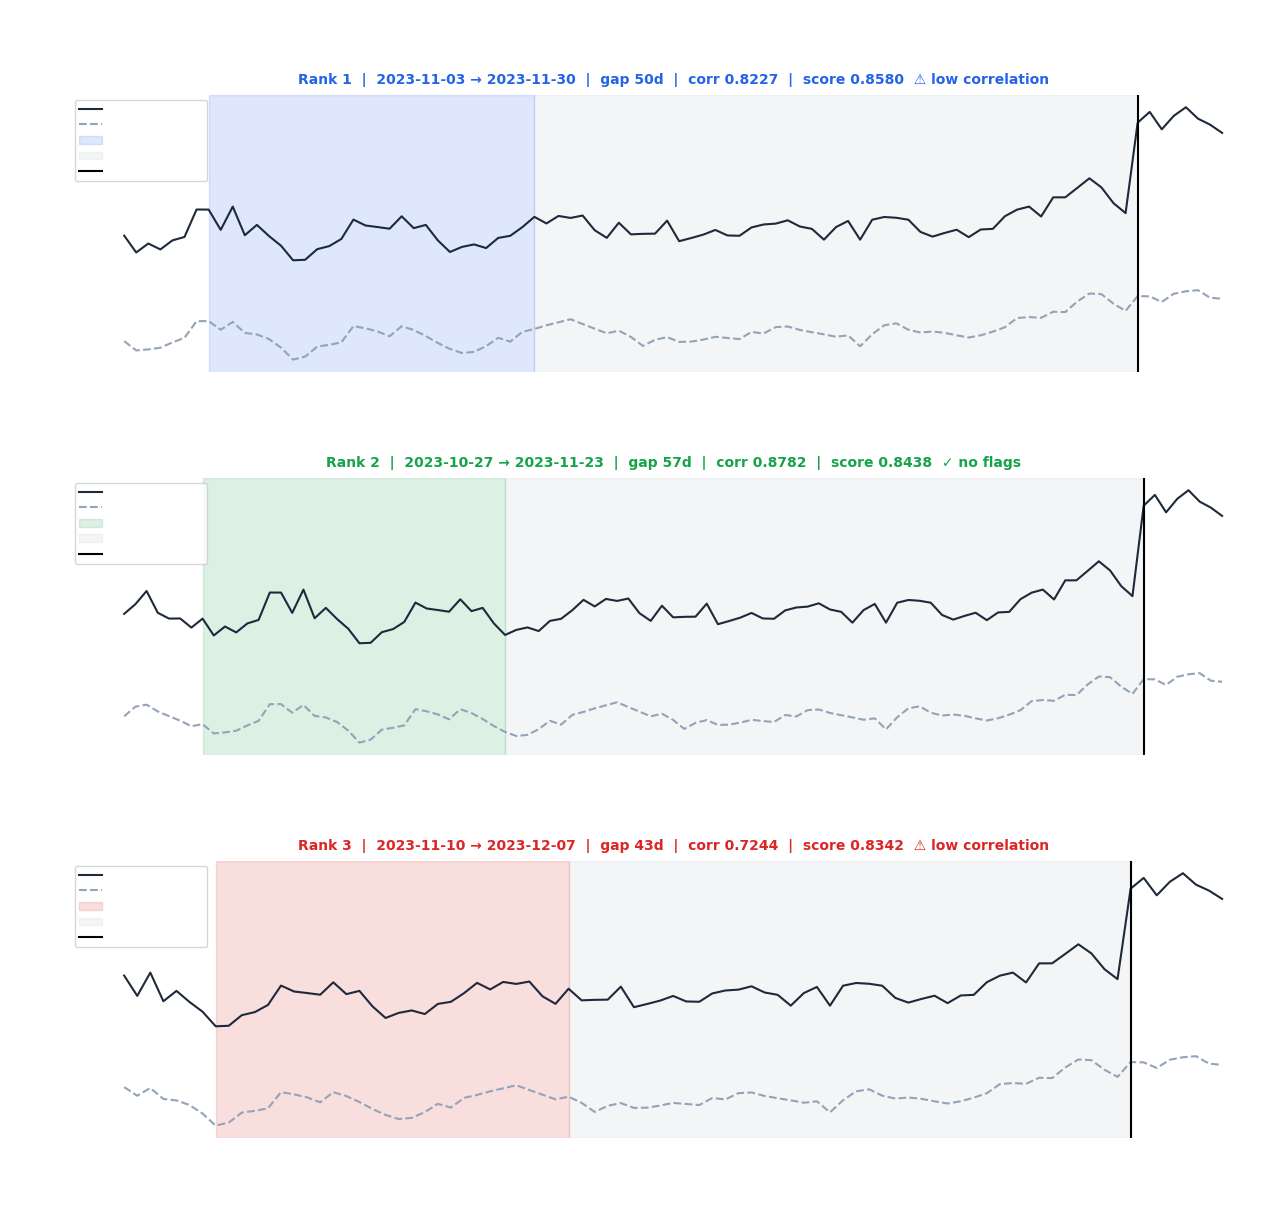

In [14]:
fig, axes = plt.subplots(len(recs), 1, figsize=(13, 4 * len(recs)), sharex=False)

for ax, (_, row) in zip(axes, recs.iterrows()):
    rank      = int(row['recommendation_rank'])
    color     = COLORS[rank - 1]
    view_start = row['pre_start'] - pd.Timedelta(days=7)
    view_end   = POST_START       + pd.Timedelta(days=7)

    window = metric[(metric['date'] >= view_start) & (metric['date'] <= view_end)]

    ax.plot(window['date'], window['treated_value'], color='#1E293B', lw=1.5, label='Treated')
    ax.plot(window['date'], window['control_value'], color='#94A3B8', lw=1.5, linestyle='--', label='Control')

    # pre-period band
    ax.axvspan(row['pre_start'], row['pre_end'], alpha=0.15, color=color, label='Pre-period')

    # gap band
    ax.axvspan(row['pre_end'], POST_START, alpha=0.07, color='#6B7280', label=f"Gap ({int(row['gap_days'])}d)")

    # post start
    ax.axvline(POST_START, color='black', lw=1.5, linestyle='-', label='Post-period start')

    # flags
    flags = []
    if pd.notna(row.get('flag_low_correlation')):  flags.append('⚠ low correlation')
    if pd.notna(row.get('flag_unstable_gap')):     flags.append('⚠ unstable gap')
    if pd.notna(row.get('flag_low_obs_count')):    flags.append('⚠ low obs count')
    flag_str = '  ' + '  '.join(flags) if flags else '  ✓ no flags'

    title = (
        f"Rank {rank}  |  {row['pre_start'].date()} → {row['pre_end'].date()}  "
        f"|  gap {int(row['gap_days'])}d  "
        f"|  corr {row['diff_corr']:.4f}  "
        f"|  score {row['composite_score']:.4f}"
        f"{flag_str}"
    )
    ax.set_title(title, fontsize=10, fontweight='bold', color=color, pad=8)
    ax.legend(fontsize=8, loc='upper left', framealpha=0.8)
    ax.set_ylabel('Metric Value')
    ax.xaxis.set_tick_params(rotation=30)

plt.suptitle('Per-Candidate Detail View', fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('pre_period_detail.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Gap Stability — Treated minus Control over Time

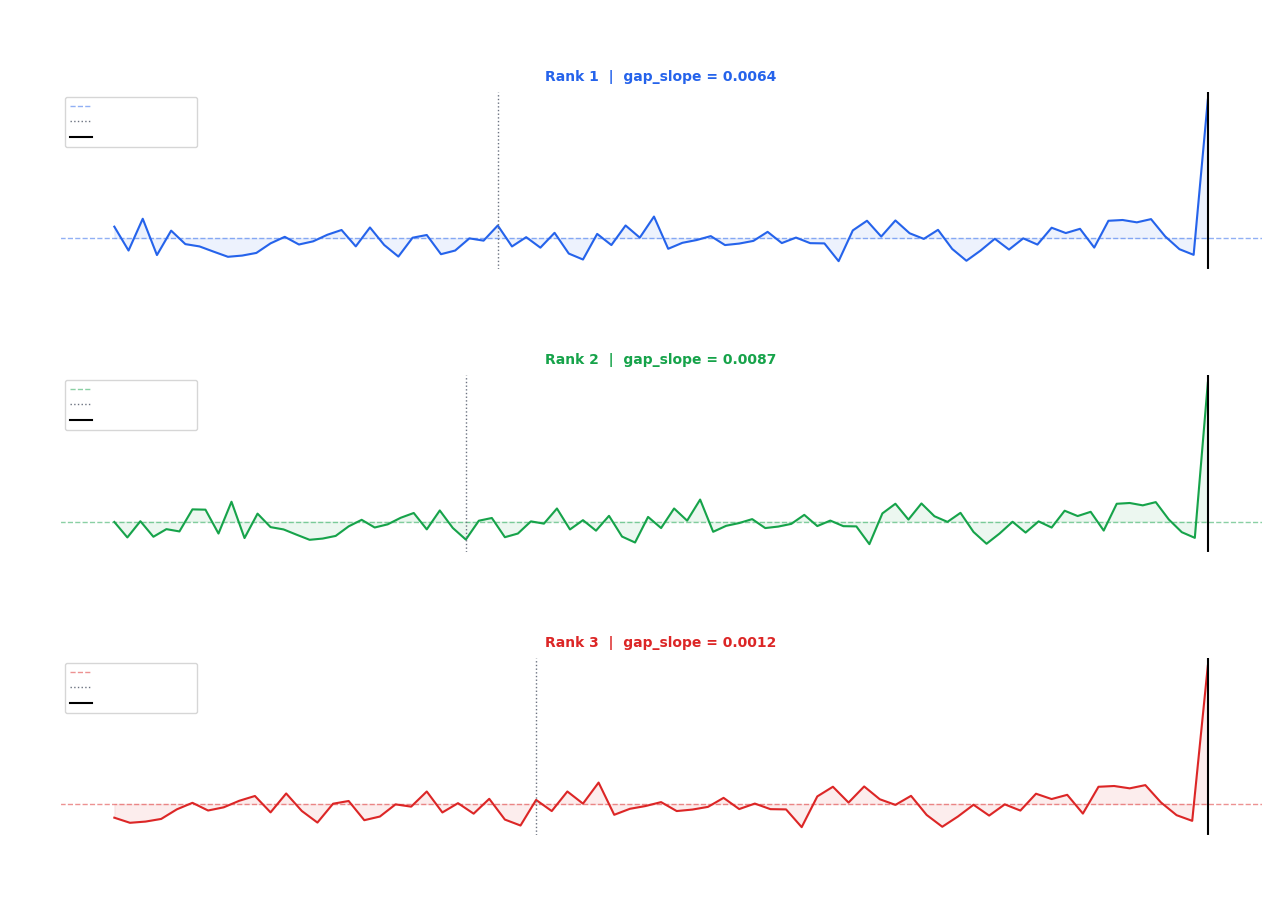

In [15]:
fig, axes = plt.subplots(len(recs), 1, figsize=(13, 3 * len(recs)), sharex=False)

for ax, (_, row) in zip(axes, recs.iterrows()):
    rank   = int(row['recommendation_rank'])
    color  = COLORS[rank - 1]

    # show from pre_start to post_start
    window = metric[
        (metric['date'] >= row['pre_start']) &
        (metric['date'] <= POST_START)
    ].copy()
    window['gap'] = window['treated_value'] - window['control_value']

    ax.plot(window['date'], window['gap'], color=color, lw=1.5)
    ax.axhline(window['gap'].mean(), color=color, lw=1, linestyle='--', alpha=0.5, label='Mean gap')
    ax.axvline(row['pre_end'],  color='#6B7280', lw=1, linestyle=':', label='Pre-period end')
    ax.axvline(POST_START,      color='black',   lw=1.5, label='Post-period start')
    ax.fill_between(window['date'], window['gap'], window['gap'].mean(), alpha=0.08, color=color)

    ax.set_title(
        f"Rank {rank}  |  gap_slope = {row['gap_slope']:.4f}",
        fontsize=10, fontweight='bold', color=color, pad=8
    )
    ax.set_ylabel('Treated − Control')
    ax.legend(fontsize=8, loc='upper left')
    ax.xaxis.set_tick_params(rotation=30)

plt.suptitle('Gap Stability (Treated − Control)', fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('pre_period_gap_stability.png', dpi=150, bbox_inches='tight')
plt.show()